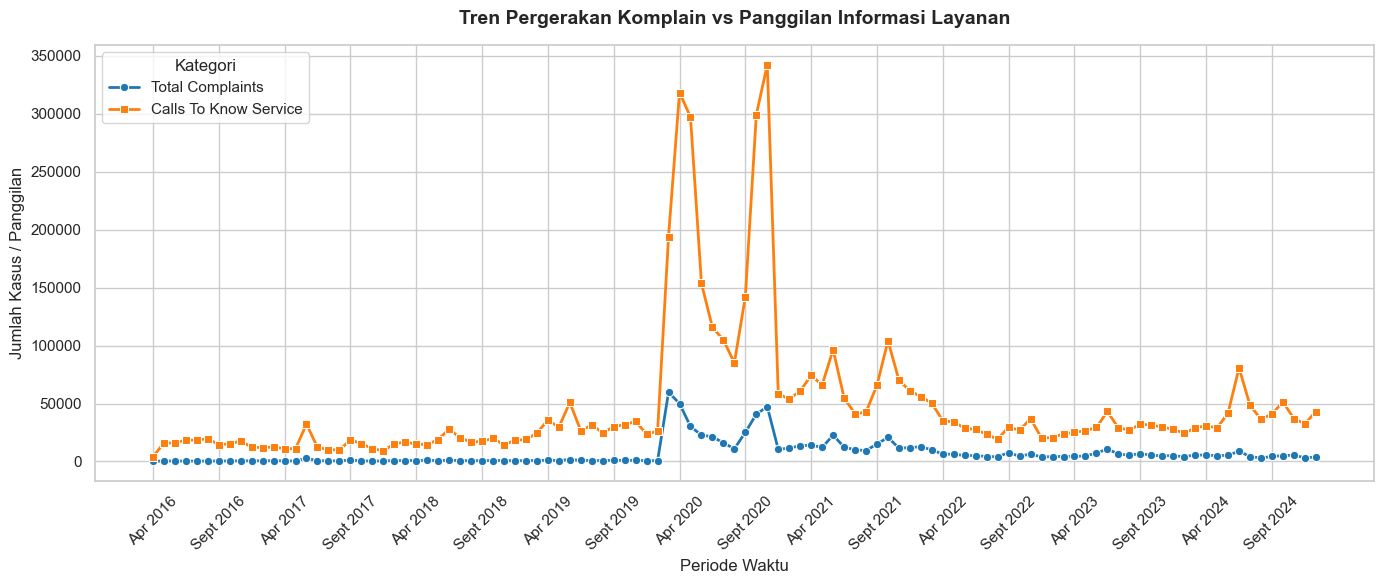

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Membaca file data
df = pd.read_csv('Kelas G_Fixed Call Report (1).csv')

# 2. Mengurutkan data secara kronologis (dari masa lalu ke terbaru)
month_map = {'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'May':5, 'Jun':6, 
             'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12}
df['Month_Num'] = df['Month'].map(month_map)
df = df.sort_values(by=['Year', 'Month_Num']).reset_index(drop=True)

# Membuat kolom label waktu gabungan (contoh: "Jan 2024")
df['Time_Label'] = df['Month'] + ' ' + df['Year'].astype(str)

# 3. Mengatur ukuran grafik dan tema
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# 4. Membuat Grafik Garis (Line Chart) untuk kedua variabel
sns.lineplot(
    data=df, x=df.index, y='Number of Total Complaints', 
    marker='o', color='#1f77b4', linewidth=2, label='Total Complaints'
)
sns.lineplot(
    data=df, x=df.index, y='Number of Calls To Know About The Service', 
    marker='s', color='#ff7f0e', linewidth=2, label='Calls To Know Service'
)

# 5. Mengatur agar label sumbu X tidak terlalu padat (ditampilkan per 6 bulan)
plt.xticks(ticks=range(0, len(df), 6), labels=df['Time_Label'].iloc[::6], rotation=45)

# 6. Menambahkan Judul, Label, dan Legend
plt.title('Tren Pergerakan Komplain vs Panggilan Informasi Layanan', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Periode Waktu', fontsize=12)
plt.ylabel('Jumlah Kasus / Panggilan', fontsize=12)
plt.legend(title='Kategori', loc='upper left')

# 7. Menampilkan Grafik
plt.tight_layout()
plt.show()